### Vanishing and Exploding Gradients Problems in Deep Learning:
- To train deep neural networks effectively, managing the vanishing and Exploding Gradients Problems is important.
- These issues occur during backpropagation when gradients become too small or too large, making it difficult for the model to learn properly.
- Both problems directly affect the model's convergence and overall performance.
### Vanishing Gradient Problem:
- Vanishing gradients occur when gradients become extremly small during backpropagation, causing early layers to learn very slowly or stop learning.
- During backpropagation the gradient of the loss L with respect to a weoght w(i) in layer i is calculated using the chain rule -
  - ∂L/∂w(i) = ∂L/∂a(n). ∂a(n)/∂a(n-1) . ∂a(n-1)/∂a(n-2)....∂a(i)/∂w(i)
  - where,
    - L - Loss Function.
    - w(i) - weights paramter in the layer.
    - a(n) - Activation output of layer.
    - ∂L/∂w(i) - Gradient of loss with respect to weight.
- When activation functions like Sigmoid or Tanh are used, their derivatives are less than 1.
- Repeated multiplication through layers causes the gradient to vanish as it moves backwards, making the lower layers unable to learn.
### Exploding Gradient Problem:
- Exploding gradients occur when gradients grow too large during backpropagation, leading to unstable weight updates and divergence in loss.
- When derivatives or weights are greater than 1, their repeated multiplication across layers to exponential growth.
- The gradient update rule in gradient descent is -
  - w(t+1) = w(t) - η . ∂L/∂w(t).
  - where,
    - w(i) - current weight value at time step t.
    - η - Learning rate
    - ∂L/∂w(i) - Gradient of loss with respect to weight.
    - w(t+1) - Updated weight after applying gradient descent.
- If ∂L/∂w(t) is too large weight updates become massive causing the model loss to oscillate or diverge.

### Why do the Gradients Vanish or Explode:
- Activation Function - Sigmoid or Tanh have small derivatives that shrink exploding gradients.
- Weight Initialization - Too small or Too large weights cause vanishing or exploding gradients.
- Deep Networks - Many layers multiply gradients repeatedly leading to instability.
- Learning rate - High learning rate or unscaled inputs can make gradients explode.

### Techniques to Fix Vanishing and Exploding Gradients:
#### 1. Proper Weight Initialization:
- Choosing right weight initialization keeps gradients balanced during backpropagation.
  - Xavier Initialization - Keeps activation variance consistent across layers to stabilize gradients.
  - Kaiming Initialization - Scales weights for ReLU to preserve signal strength and prevent gradient decay.
#### 2. Use Non Saturating Activation Functions:
- Sigmoid or Tanh can shrink gradients. Using ReLU or its variants prevents vanishing gradients.
  - ReLU - Basic rectified linear unit.
  - Leaky ReLU - Allows small gradients for negative inputs.
  - ELU/SELU - Helps maintain self normalizing properties.
#### 3. Apply Batch Normalization:
- Normalizes layer inputs to have zero mean and unit variance, stabilizing gradients and accelerating convergence.
#### 4. Gradient Clipping:
- Limits gradients to a maximum threshold to prevent them from exploding and destabilizing training.

### Step-By-Step Implementation:

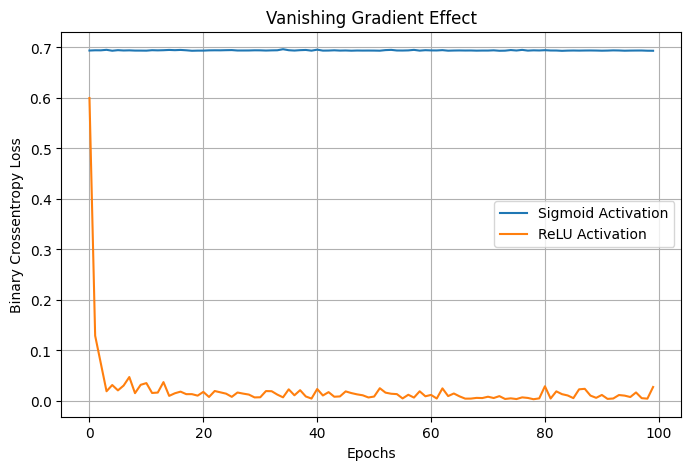

In [5]:
# Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Create a Simple Dataset
np.random.seed(42)
X = np.random.randn(2000, 2)
y = (X[:, 0] + X[:, 1] > 0).astype(int)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Define a Deep Neural Network
def build_network(activations, layers=20):
    model = Sequential()
    model.add(tf.keras.Input(shape=(2,)))
    model.add(Dense(32, activation=activations))

    for _ in range(layers - 1):
        model.add(Dense(32, activation=activations))
        
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')
        
    return model

sigmoid_model = build_network('sigmoid', layers=20)


# Train Model with Sigmoid Activation
sigmoid_history = sigmoid_model.fit(x_train, y_train, epochs=100, batch_size=32, verbose=0)

relu_model = build_network('relu', layers=20)


# Train Model with ReLU Activation
relu_history = relu_model.fit(x_train, y_train, epochs=100, batch_size=32, verbose=0)


# Plot Training Loss Curves
plt.figure(figsize=(8,5))
plt.plot(sigmoid_history.history['loss'], label='Sigmoid Activation')
plt.plot(relu_history.history['loss'], label='ReLU Activation')
plt.xlabel('Epochs')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Vanishing Gradient Effect')
plt.legend()
plt.grid(True)
plt.show()